In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import os
import EFC_learningfMRI.globals as gl
from nitools import spm as spm
import pandas as pd

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [5]:
H = 'L'
rois = gl.rois['ROI']
glm = 3
sns = [101, 102, 103, 104, 105, 106, 107, 108, 110]
pairs = [('delay_response', 'delay_undershoot'), ('delay_undershoot', 'ratio'), ('delay_response', 'ratio')]
hrf = pd.read_csv(os.path.join(gl.baseDir, f'glm{glm}', 'hrf_fitted.tsv'), sep='\t')
hrf = hrf.melt(id_vars=['roi', 'Hem', 'time', 'kind'], value_vars=[str(sn) for sn in sns], var_name='sn', value_name='BOLD')

/localscratch/tmp/ipykernel_195695/876943862.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, bbox_to_anchor=(1, -.1), loc='upper right', )


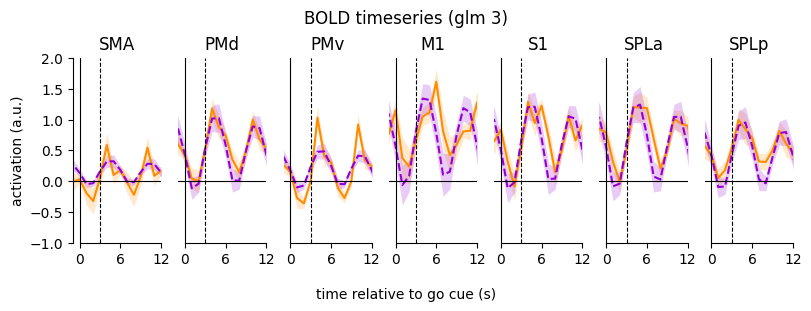

In [6]:
fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]
    data = hrf[(hrf.Hem==H) & (hrf.roi==roi)]
    sb.lineplot(data=data[data.kind=='adj'], ax=ax, x='time', y='BOLD', errorbar='se', color='darkorange', err_kws={'linewidth': 0})
    sb.lineplot(data=data[data.kind=='hat'], ax=ax, x='time', y='BOLD', errorbar='se', color='darkviolet', ls='--', err_kws={'linewidth': 0})
    
    ax.axvline(0, color='k', ls='-', lw=.8)
    ax.axvline(3, color='k', ls='--', lw=.8)
    ax.axhline(0, color='k', ls='-', lw=.8)

    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.spines['bottom'].set_bounds(0, 12)
    ax.set_xticks([0, 6, 12])
    if r == 0:
        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_bounds(-1, 2)
    else:
        ax.tick_params('y', width=0)

    ax.set_xlim((-1, 12))
    ax.set_xlabel(None)
    ax.set_ylim((-1, 2))

    ax.set_title(rois[r])

ax.legend(frameon=False, bbox_to_anchor=(1, -.1), loc='upper right', )

axs[0].set_ylabel('activation (a.u.)')
fig.supxlabel('time relative to go cue (s)', fontsize=10)
fig.suptitle(f'BOLD timeseries (glm {glm})')
#fig.tight_layout()

plt.show()